In [1]:
!pip install timm --no-deps -q

import os
from pathlib import Path
import random
import numpy as np

import cv2
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

DATA_ROOT = Path("/kaggle/input/deep-fake-detection-dfd-entire-original-dataset")
OUT_ROOT  = Path("/kaggle/working/dfd_faces")  

NUM_FRAMES = 16
IMG_SIZE   = 224
BATCH_SIZE = 4
EPOCHS     = 25
LR         = 1e-4
SEED       = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
OUT_ROOT.mkdir(parents=True, exist_ok=True)


Using: cuda


In [2]:
real_dir = DATA_ROOT / "DFD_original sequences"
fake_dir = DATA_ROOT / "DFD_manipulated_sequences" / "DFD_manipulated_sequences"

real_videos = sorted([p for p in real_dir.glob("*.mp4")])
fake_videos = sorted([p for p in fake_dir.glob("*.mp4")])[:400]

print("Num real:", len(real_videos))
print("Num fake:", len(fake_videos))

all_paths = real_videos + fake_videos
all_labels = [1]*len(real_videos) + [0]*len(fake_videos)   # 1: real, 0: fake

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, random_state=SEED, stratify=train_labels
)

def build_split_list(paths, labels):
    return [{"path": p, "label": int(l)} for p, l in zip(paths, labels)]

splits = {
    "train": build_split_list(train_paths, train_labels),
    "val":   build_split_list(val_paths,   val_labels),
    "test":  build_split_list(test_paths,  test_labels),
}

for k,v in splits.items():
    print(k, len(v))


Num real: 363
Num fake: 400
train 488
val 122
test 153


In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def center_crop_resize(img, size=224):
    h, w = img.shape[:2]
    side = min(h, w)
    cx, cy = w // 2, h // 2
    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    crop = img[y1:y1+side, x1:x1+side]
    return cv2.resize(crop, (size, size))

def detect_face_crop(img, size=224):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3,
                                          minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return center_crop_resize(img, size), False

    x, y, w, h = max(faces, key=lambda b: b[2]*b[3])
    x1, y1, x2, y2 = x, y, x+w, y+h
    face = img[y1:y2, x1:x2]
    face = cv2.resize(face, (size, size))
    return face, True

def extract_faces_from_video(video_path: Path, out_dir: Path,
                             num_frames=16, img_size=224):
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print("Cannot open:", video_path)
        return 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        print("No frames:", video_path)
        cap.release()
        return 0

    indices = np.linspace(0, total-1, num_frames, dtype=int)

    saved = 0
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok or frame is None:
            continue
        face, _ = detect_face_crop(frame, size=img_size)
        out_path = out_dir / f"{i:03d}.jpg"
        cv2.imwrite(str(out_path), face)
        saved += 1

    cap.release()
    return saved


In [4]:
def get_class_name(label_int):
    return "real" if label_int == 1 else "fake"

for split_name, items in splits.items():
    print("Processing", split_name, "...")
    for info in items:
        vpath = info["path"]
        label = info["label"]
        cls_name = get_class_name(label)

        video_id = vpath.stem  
        out_dir = OUT_ROOT / split_name / cls_name / video_id

        if out_dir.exists():
            continue

        n_saved = extract_faces_from_video(vpath, out_dir,
                                           num_frames=NUM_FRAMES,
                                           img_size=IMG_SIZE)
        if n_saved == 0:
            if out_dir.exists():
                for f in out_dir.glob("*.jpg"):
                    f.unlink()
                out_dir.rmdir()
    print("Done", split_name)

print("Preprocessing finished. Root:", OUT_ROOT)


Processing train ...
Done train
Processing val ...
Done val
Processing test ...
Done test
Preprocessing finished. Root: /kaggle/working/dfd_faces


In [5]:
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torch

class VideoFaceDataset(Dataset):
    def __init__(self, root, num_frames=16, img_size=224):
        self.root = Path(root)
        self.num_frames = num_frames

        self.classes = ["fake", "real"]
        self.class_to_idx = {"fake": 0, "real": 1}

        self.samples = []
        for cls in self.classes:
            cdir = self.root / cls
            if not cdir.exists():
                continue
            for video_dir in sorted(cdir.iterdir()):
                if video_dir.is_dir():
                    frames = sorted(video_dir.glob("*.jpg"))
                    if len(frames) == 0:
                        continue
                    self.samples.append((video_dir, self.class_to_idx[cls]))

        print(f"Dataset @ {root}: {len(self.samples)} clips")

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406],
                        std=[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def _sample_frames(self, frame_paths):
        n = len(frame_paths)
        if n >= self.num_frames:
            idx = np.linspace(0, n-1, self.num_frames, dtype=int)
        else:
            idx = list(range(n)) + [n-1]*(self.num_frames-n)
        return [frame_paths[i] for i in idx]

    def __getitem__(self, idx):
        video_dir, label = self.samples[idx]
        frames = sorted(video_dir.glob("*.jpg"))
        frames = self._sample_frames(frames)

        imgs = []
        for p in frames:
            img = Image.open(p).convert("RGB")
            img = self.transform(img)
            imgs.append(img)

        frames_tensor = torch.stack(imgs, dim=0)  # (T,C,H,W)
        return frames_tensor, torch.tensor(label, dtype=torch.long)

FACE_ROOT = OUT_ROOT   

NUM_FRAMES = 16
IMG_SIZE   = 224
BATCH_SIZE = 8

train_img_ds = VideoFaceDataset(FACE_ROOT / "train", NUM_FRAMES, IMG_SIZE)
val_img_ds   = VideoFaceDataset(FACE_ROOT / "val",   NUM_FRAMES, IMG_SIZE)
test_img_ds  = VideoFaceDataset(FACE_ROOT / "test",  NUM_FRAMES, IMG_SIZE)

train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
val_img_loader   = DataLoader(val_img_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
test_img_loader  = DataLoader(test_img_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)


Dataset @ /kaggle/working/dfd_faces/train: 488 clips
Dataset @ /kaggle/working/dfd_faces/val: 122 clips
Dataset @ /kaggle/working/dfd_faces/test: 153 clips


In [6]:
import timm
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

def get_effnet_extractor(model_name="tf_efficientnet_b0_ns"):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=0,   
        global_pool="avg"
    )
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model

effnet = get_effnet_extractor().to(device)
FEATURE_DIM = effnet.num_features
print("Feature dim:", FEATURE_DIM)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using: cuda


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Feature dim: 1280


In [7]:
from tqdm import tqdm

@torch.no_grad()
def extract_features_split(loader, save_path):
    all_feats = []
    all_labels = []

    for frames, labels in tqdm(loader, desc=f"Extracting -> {save_path}"):
        #
        B, T, C, H, W = frames.shape
        frames = frames.to(device)

        frames_flat = frames.view(B*T, C, H, W)    # (B*T,C,H,W)
        feats_flat = effnet(frames_flat)           # (B*T,F)
        feats = feats_flat.view(B, T, -1)          # (B,T,F)

        all_feats.append(feats.cpu())
        all_labels.append(labels.clone())

    X = torch.cat(all_feats, dim=0)   # (N,T,F)
    y = torch.cat(all_labels, dim=0)  # (N,)
    torch.save({"features": X, "labels": y}, save_path)
    print(f"Saved {save_path}: X={X.shape}, y={y.shape}")

SAVE_ROOT = Path("/kaggle/working/dfd_effnet_features")
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

extract_features_split(train_img_loader, SAVE_ROOT / "train_features.pt")
extract_features_split(val_img_loader,   SAVE_ROOT / "val_features.pt")
extract_features_split(test_img_loader,  SAVE_ROOT / "test_features.pt")


Extracting -> /kaggle/working/dfd_effnet_features/train_features.pt: 100%|██████████| 61/61 [00:10<00:00,  5.79it/s]


Saved /kaggle/working/dfd_effnet_features/train_features.pt: X=torch.Size([488, 16, 1280]), y=torch.Size([488])


Extracting -> /kaggle/working/dfd_effnet_features/val_features.pt: 100%|██████████| 16/16 [00:02<00:00,  5.64it/s]


Saved /kaggle/working/dfd_effnet_features/val_features.pt: X=torch.Size([122, 16, 1280]), y=torch.Size([122])


Extracting -> /kaggle/working/dfd_effnet_features/test_features.pt: 100%|██████████| 20/20 [00:03<00:00,  5.91it/s]

Saved /kaggle/working/dfd_effnet_features/test_features.pt: X=torch.Size([153, 16, 1280]), y=torch.Size([153])


In [8]:
class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, path):
        data = torch.load(path)
        self.X = data["features"]  # (N,T,F)
        self.y = data["labels"]    # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_feat_ds = FeatureDataset(SAVE_ROOT / "train_features.pt")
val_feat_ds   = FeatureDataset(SAVE_ROOT / "val_features.pt")
test_feat_ds  = FeatureDataset(SAVE_ROOT / "test_features.pt")

train_feat_loader = DataLoader(train_feat_ds, batch_size=64, shuffle=True)
val_feat_loader   = DataLoader(val_feat_ds,   batch_size=64, shuffle=False)
test_feat_loader  = DataLoader(test_feat_ds,  batch_size=64, shuffle=False)

print("Train features:", train_feat_ds.X.shape)


Train features: torch.Size([488, 16, 1280])


In [9]:
import math
import torch.nn.functional as F

class TemporalViT(nn.Module):
    def __init__(self,
                 feature_dim=FEATURE_DIM,
                 d_model=256,
                 n_heads=4,
                 num_layers=4,
                 num_classes=2,
                 dropout=0.1,
                 max_len=64):
        super().__init__()

        self.proj = nn.Linear(feature_dim, d_model)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len+1, d_model))  # +1 cho CLS

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        # x: (B,T,F)
        B, T, Fd = x.shape
        x = self.proj(x)                   # (B,T,d_model)

        cls = self.cls_token.expand(B, -1, -1)  # (B,1,d_model)
        x = torch.cat([cls, x], dim=1)          # (B,T+1,d_model)

        x = x + self.pos_embed[:, :T+1, :]      # add positional encoding

        h = self.encoder(x)                     # (B,T+1,d_model)
        cls_out = h[:, 0]                     
        cls_out = self.norm(cls_out)
        logits = self.fc(cls_out)
        return logits

num_classes = 2
vit_model = TemporalViT(
    feature_dim=FEATURE_DIM,
    d_model=256,
    n_heads=4,
    num_layers=4,
    num_classes=num_classes,
    max_len=NUM_FRAMES
).to(device)

print(vit_model)


TemporalViT(
  (proj): Linear(in_features=1280, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [10]:
def get_class_weights_from_feat_ds(dataset):
    labels = dataset.y
    counts = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (counts * len(counts) + 1e-8)
    return weights

class_weights = get_class_weights_from_feat_ds(train_feat_ds).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

def train_epoch():
    vit_model.train()
    total_loss, correct, total = 0., 0, 0
    for X, y in train_feat_loader:
        X, y = X.to(device), y.to(device)   # X: (B,T,F)
        logits = vit_model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss/len(train_feat_loader), correct/total

@torch.no_grad()
def eval_epoch(loader):
    vit_model.eval()
    total_loss, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = vit_model(X)
        loss = criterion(logits, y)
        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss/len(loader), correct/total

EPOCHS = 60
best_val = 0.0
best_path = "/kaggle/working/best_temporal_vit.pth"

hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch()
    val_loss, val_acc = eval_epoch(val_feat_loader)
    scheduler.step()

    hist["train_loss"].append(tr_loss)
    hist["val_loss"].append(val_loss)
    hist["train_acc"].append(tr_acc)
    hist["val_acc"].append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(vit_model.state_dict(), best_path)
        print(f"[Epoch {ep:02d}] New best val_acc={val_acc*100:.2f}%, saved!")

    print(f"Epoch {ep:02d} | "
          f"Train {tr_loss:.4f}/{tr_acc*100:.2f}% | "
          f"Val {val_loss:.4f}/{val_acc*100:.2f}%")

print("Best Val Acc:", best_val*100)


Class weights: tensor([0.9531, 1.0517], device='cuda:0')
[Epoch 01] New best val_acc=72.13%, saved!
Epoch 01 | Train 0.6711/59.84% | Val 0.6204/72.13%
[Epoch 02] New best val_acc=78.69%, saved!
Epoch 02 | Train 0.4461/80.94% | Val 0.4478/78.69%
[Epoch 03] New best val_acc=81.97%, saved!
Epoch 03 | Train 0.3431/85.86% | Val 0.3737/81.97%
[Epoch 04] New best val_acc=85.25%, saved!
Epoch 04 | Train 0.2690/90.98% | Val 0.3331/85.25%
[Epoch 05] New best val_acc=87.70%, saved!
Epoch 05 | Train 0.2113/91.19% | Val 0.3135/87.70%
[Epoch 06] New best val_acc=88.52%, saved!
Epoch 06 | Train 0.1987/92.62% | Val 0.2594/88.52%
[Epoch 07] New best val_acc=90.98%, saved!
Epoch 07 | Train 0.1517/94.67% | Val 0.2306/90.98%
[Epoch 08] New best val_acc=91.80%, saved!
Epoch 08 | Train 0.1364/94.67% | Val 0.2199/91.80%
Epoch 09 | Train 0.1338/94.67% | Val 0.2484/88.52%
Epoch 10 | Train 0.1408/94.06% | Val 0.2786/89.34%
[Epoch 11] New best val_acc=93.44%, saved!
Epoch 11 | Train 0.1180/96.11% | Val 0.2056/93

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

vit_model.load_state_dict(torch.load(best_path))
vit_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X, y in test_feat_loader:
        X = X.to(device)
        logits = vit_model(X)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

# Precision, Recall, F1-score
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# ROC–AUC
auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC:", auc)



Classification Report:

              precision    recall  f1-score   support

        Fake       0.94      0.97      0.96        80
        Real       0.97      0.93      0.95        73

    accuracy                           0.95       153
   macro avg       0.96      0.95      0.95       153
weighted avg       0.95      0.95      0.95       153

Confusion Matrix:
 [[78  2]
 [ 5 68]]
ROC-AUC: 0.9825342465753425


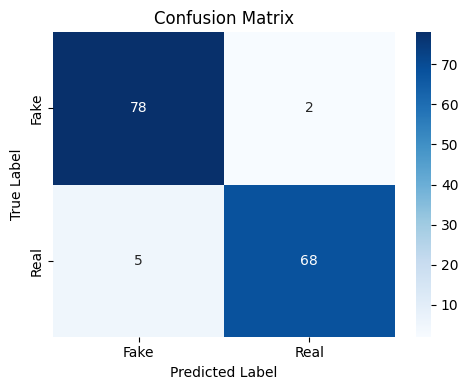

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


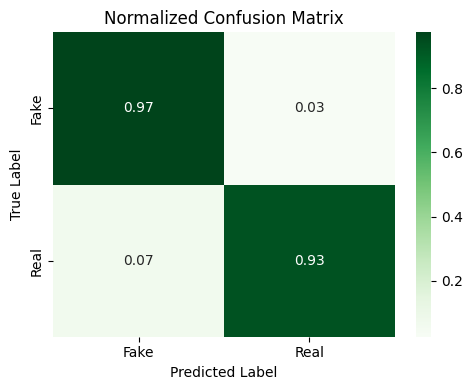

In [13]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

plt.figure(figsize=(5,4))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            cmap="Greens")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


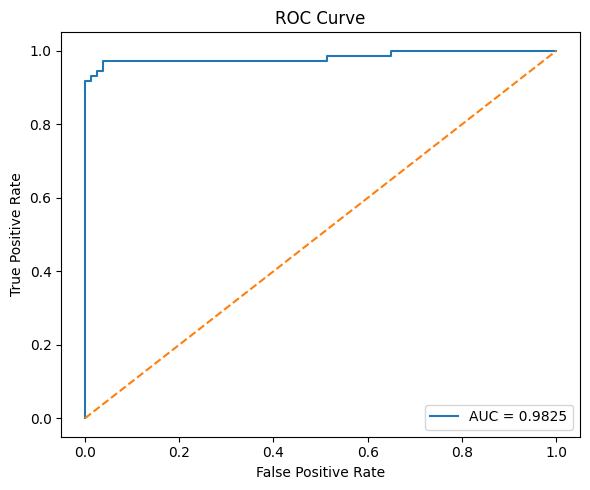

In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


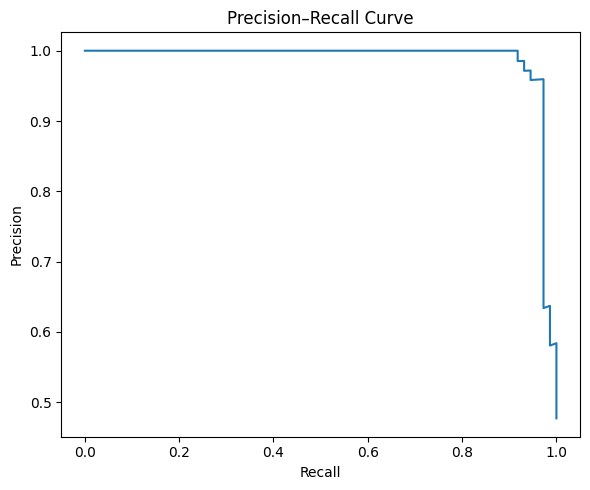

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.show()


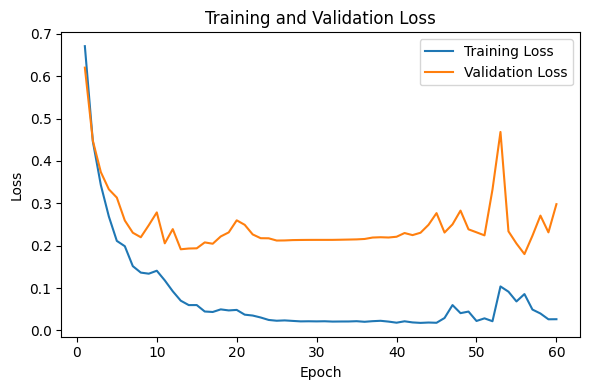

In [16]:
epochs = range(1, len(hist["train_loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, hist["train_loss"], label="Training Loss")
plt.plot(epochs, hist["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


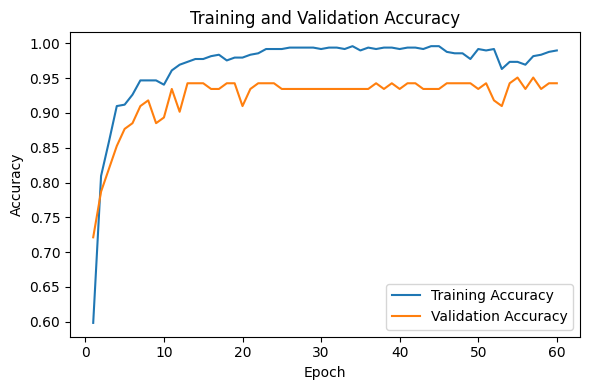

In [17]:
plt.figure(figsize=(6,4))
plt.plot(epochs, hist["train_acc"], label="Training Accuracy")
plt.plot(epochs, hist["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


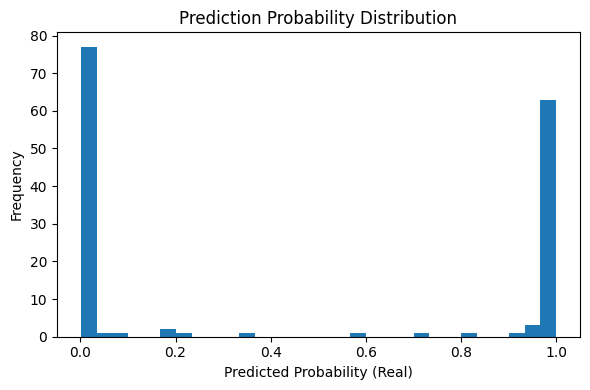

In [18]:
plt.figure(figsize=(6,4))
plt.hist(all_probs, bins=30)

plt.xlabel("Predicted Probability (Real)")
plt.ylabel("Frequency")
plt.title("Prediction Probability Distribution")
plt.tight_layout()
plt.show()


In [19]:
# ==============================================================================
# DOWNLOAD AND DEPLOYMENT SETUP (SHOW FILES + AUTO DOWNLOAD)
# ==============================================================================

import json
from IPython.display import display, Javascript, Markdown
from IPython.display import FileLink

# 1. Export Model Metadata
metadata = {
    "IMG_SIZE": IMG_SIZE,
    "NUM_FRAMES": NUM_FRAMES,
    "FEATURE_DIM": FEATURE_DIM,
    "ARCH": "tf_efficientnet_b0_ns + TemporalViT",
    "CLASSES": ["Fake", "Real"]
}

with open("/kaggle/working/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# 2. Files to download
files = [
    "best_temporal_vit.pth",
    "model_metadata.json"
]

# 3. SHOW files clearly in output
display(Markdown("### 📦 Files prepared for download:"))
for f in files:
    display(Markdown(f"- `{f}`"))

# 4. AUTO-DOWNLOAD (no click required)
js_code = """
(function() {
    const files = %s;
    files.forEach((file, i) => {
        setTimeout(() => {
            const link = document.createElement('a');
            link.href = '/kaggle/working/' + file;
            link.download = file;
            document.body.appendChild(link);
            link.click();
            document.body.removeChild(link);
        }, i * 800);  // delay to avoid browser blocking
    });
})();
""" % files

display(Javascript(js_code))

display(FileLink(r'best_temporal_vit.pth'))
display(FileLink(r'model_metadata.json'))

### 📦 Files prepared for download:

- `best_temporal_vit.pth`

- `model_metadata.json`

<IPython.core.display.Javascript object>

/kaggle/working/best_temporal_vit.pth

/kaggle/working/model_metadata.json